The purpose of this notebook is to figure out the best way to build a classifier to determine roughly how effective a certain parameterization of mel2vec will be.
This will be compared against Perch, which is our baseline transfer learning model.

In [1]:
from pathlib import Path
import polars as pl
from birdclef.config import colombia_species_list
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import classification_report
from pacmap import PaCMAP
import matplotlib.pyplot as plt

shared = Path("~/shared/birdclef").expanduser()
perch = pl.scan_parquet(
    f"{shared}/data/2025/train_audio-infer-soundscape/Perch/parts/embed/*.parquet"
)
columns = perch.collect_schema().names()
perch = (
    perch.select(
        "file",
        "start_time",
        "end_time",
        (
            pl.concat_list(columns[3:])
            .list.to_array(len(columns[3:]))
            .alias("embedding")
        ),
    )
    .sort("file", "start_time")
    .with_columns(
        species=pl.col("file").str.split("/").list.get(-2),
        track=pl.col("file").str.split("/").list.get(-1).str.split(".").list.first(),
    )
)
# count and schema
display(perch.collect_schema())

Schema([('file', String),
        ('start_time', Float64),
        ('end_time', Float64),
        ('embedding', Array(Float64, shape=(1280,))),
        ('species', String),
        ('track', String)])

In [2]:
# # give me distinct species
# species = perch.select(pl.col("species")).unique().sort("species")
# # get the species as a list
# species.collect().to_pandas().species.to_list()

In [3]:
df = (
    perch.filter(pl.col("species").is_in(colombia_species_list))
    .select("species", "embedding")
    .collect()
    .to_pandas()
)
df.shape

(19003, 2)

In [4]:
df.species.value_counts()

species
socfly1    3347
strcuc1    2862
tropar     2578
strfly1    2443
butsal1    2282
52884      1191
blhpar1    1006
cattyr      808
eardov1     500
neocor      491
blkvul      402
555086      259
67252       231
savhaw1     230
1462737     140
65344        92
1192948      83
41778        40
47067        14
42113         4
Name: count, dtype: int64

In [5]:
X = np.stack(df["embedding"].values)
y = df["species"].values
le = LabelEncoder()
y = le.fit_transform(y)
# stratify the split by species
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_micro = f1_score(y_test, y_pred, average="micro")
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

report = classification_report(y_test, y_pred, target_names=le.classes_)
print(report)

F1 Macro: 0.7971
F1 Micro: 0.9132
ROC AUC: 0.9950
              precision    recall  f1-score   support

     1192948       0.83      0.29      0.43        17
     1462737       0.63      0.86      0.73        28
       41778       1.00      1.00      1.00         8
       42113       0.00      0.00      0.00         1
       47067       0.00      0.00      0.00         3
       52884       0.91      0.93      0.92       238
      555086       1.00      0.98      0.99        52
       65344       1.00      0.94      0.97        18
       67252       1.00      1.00      1.00        46
     blhpar1       0.96      0.91      0.93       201
      blkvul       0.87      0.81      0.84        80
     butsal1       0.95      0.95      0.95       456
      cattyr       0.96      0.92      0.94       162
     eardov1       0.89      0.81      0.85       100
      neocor       0.94      0.91      0.92        98
     savhaw1       0.90      0.76      0.82        46
     socfly1       0.89      0.

/storage/home/hcoda1/8/amiyaguchi3/clef/birdclef-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/storage/home/hcoda1/8/amiyaguchi3/clef/birdclef-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/storage/home/hcoda1/8/amiyaguchi3/clef/birdclef-2025/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

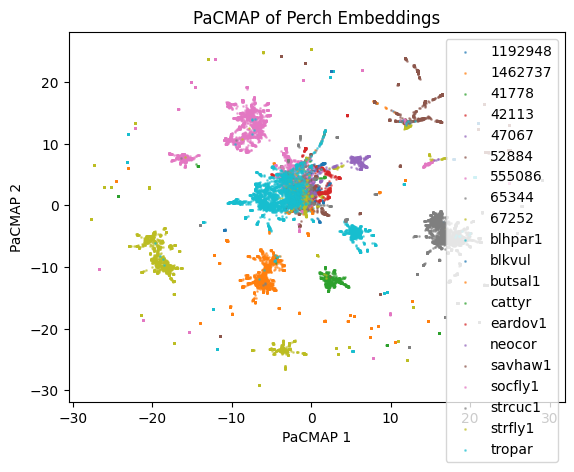

In [6]:
def plot_pacman(X, y, le, title):
    z = PaCMAP().fit_transform(X)
    for i, species in enumerate(le.classes_):
        plt.scatter(z[y == i, 0], z[y == i, 1], label=species, alpha=0.5, s=1)
    plt.legend()
    plt.xlabel("PaCMAP 1")
    plt.ylabel("PaCMAP 2")
    plt.title(title)


plot_pacman(X, y, le, "PaCMAP of Perch Embeddings")